In [30]:
SUBJECT_IDS = list(range(1, 11)) # first ten
# SUBJECT_IDS = list(range(1, 110)) # full

# executed
RUNS_FOR_TRAINING = [3, 7]
RUNS_FOR_TESTING = [11]
# # motor imagery
# RUNS_FOR_TRAINING = [4, 8]
# RUNS_FOR_TESTING = [12]
# # executed -> motor imagery
# RUNS_FOR_TRAINING = [3, 7]
# RUNS_FOR_TESTING = [12]

In [31]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mne
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

In [32]:
# 1. Data Loading and Preprocessing Function
def load_and_epoch(subject_id: int, runs: list, tmin=0.5, tmax=3.5, l_freq=8.0, h_freq=30.0):
    """
    Loads specified runs for a subject, applies bandpass filter, and extracts 3-second epochs.
    """
    file_paths = mne.datasets.eegbci.load_data(subject=subject_id, runs=runs, update_path=False)
    # might need "subjects=" instead of "subject=" if using different version of MNE
    # file_paths = mne.datasets.eegbci.load_data(subjects=subject_id, runs=runs, update_path=False)
    
    # Load each EDF and standardize channel names on ALL of them
    raws = []
    for f in file_paths:
        r = mne.io.read_raw_edf(f, preload=True)
        mne.datasets.eegbci.standardize(r)  # Strips trailing dots and cleans names
        raws.append(r)
    
    montage = mne.channels.make_standard_montage('standard_1005')
    
    raw = mne.concatenate_raws(raws)
    raw.set_montage(montage, match_case=False)
    
    # Universal preprocessing: 8-30 Hz Sensorimotor Band
    raw.filter(l_freq, h_freq, fir_design='firwin', skip_by_annotation='edge')
    
    # Extract events: T1 (Left Fist), T2 (Right Fist)
    events, event_dict = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2})
    
    # Epoching: 0.5s to 3.5s after the visual cue
    epochs = mne.Epochs(
        raw, 
        events, 
        event_id=event_dict, 
        tmin=tmin, 
        tmax=tmax, 
        baseline=None, 
        preload=True
    )
    
    X = epochs.get_data(copy=False)  # Shape: (trials, channels, timepoints)
    y = epochs.events[:, -1] - 1     # Map T1->0 (Left), T2->1 (Right)
    
    return epochs, X, y

In [33]:
# silence the mne logs if you want to avoid huge logs from next cell
mne.set_log_level('WARNING')

In [34]:
records = []
fitted_pipelines = {}
cached_train_infos = {}

print("=== Starting Intra-Subject Batch Benchmark: CSP vs RG ===")
for sub in SUBJECT_IDS:
    try:
        # 1. Load subject data
        train_epochs, X_train, y_train = load_and_epoch(sub, RUNS_FOR_TRAINING)
        test_epochs, X_test, y_test = load_and_epoch(sub, RUNS_FOR_TESTING)
        
        # 2. Pipeline 1: CSP + LDA
        pipe_csp = Pipeline([
            ("CSP", CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)),
            ("LDA", LinearDiscriminantAnalysis())
        ])
        pipe_csp.fit(X_train, y_train)
        acc_csp = pipe_csp.score(X_test, y_test)
        
        # 3. Pipeline 2: Riemannian Geometry + Logistic Regression
        pipe_rg = Pipeline([
            ("Covariances", Covariances(estimator='lwf')),
            ("TangentSpace", TangentSpace(metric='riemann')),
            ("LR", LogisticRegression(solver="lbfgs", max_iter=1000))
        ])
        pipe_rg.fit(X_train, y_train)
        acc_rg = pipe_rg.score(X_test, y_test)
        
        # 4. Store metrics
        records.append({
            "Subject": f"S{sub:02d}",
            "Subject_ID": sub,
            "CSP_Accuracy": acc_csp,
            "RG_Accuracy": acc_rg,
            "Train_Trials": len(y_train),
            "Test_Trials": len(y_test)
        })
        fitted_pipelines[sub] = {"CSP": pipe_csp, "RG": pipe_rg}
        cached_train_infos[sub] = train_epochs.info
        
        print(f"Subject {sub:02d} | CSP: {acc_csp:6.2%} | RG: {acc_rg:6.2%} (Test trials: {len(y_test)})")
        
    except Exception as e:
        print(f"Subject {sub:02d} failed: {e}")

if not records:
    raise RuntimeError("No subjects were successfully evaluated. Check run numbers or data paths.")

df_intra = pd.DataFrame(records)

=== Starting Intra-Subject Batch Benchmark: CSP vs RG ===
Subject 01 | CSP: 80.00% | RG: 80.00% (Test trials: 15)
Subject 02 | CSP: 46.67% | RG: 66.67% (Test trials: 15)
Subject 03 | CSP: 66.67% | RG: 60.00% (Test trials: 15)
Subject 04 | CSP: 73.33% | RG: 53.33% (Test trials: 15)
Subject 05 | CSP: 73.33% | RG: 66.67% (Test trials: 15)
Subject 06 | CSP: 73.33% | RG: 53.33% (Test trials: 15)
Subject 07 | CSP: 86.67% | RG: 93.33% (Test trials: 15)
Subject 08 | CSP: 53.33% | RG: 80.00% (Test trials: 15)
Subject 09 | CSP: 60.00% | RG: 46.67% (Test trials: 15)
Subject 10 | CSP: 93.33% | RG: 53.33% (Test trials: 15)



Cohort Size: 10 subjects evaluated
CSP+LDA Mean: 70.67% ± 4.58% SEM | p(1-tailed) = 7.2706e-04
RG+LR Mean:   65.33% ± 4.75% SEM | p(1-tailed) = 5.1512e-03
Paired Difference (RG - CSP): -5.33%
Paired t-test: t(9) = -0.851, p = 4.1702e-01


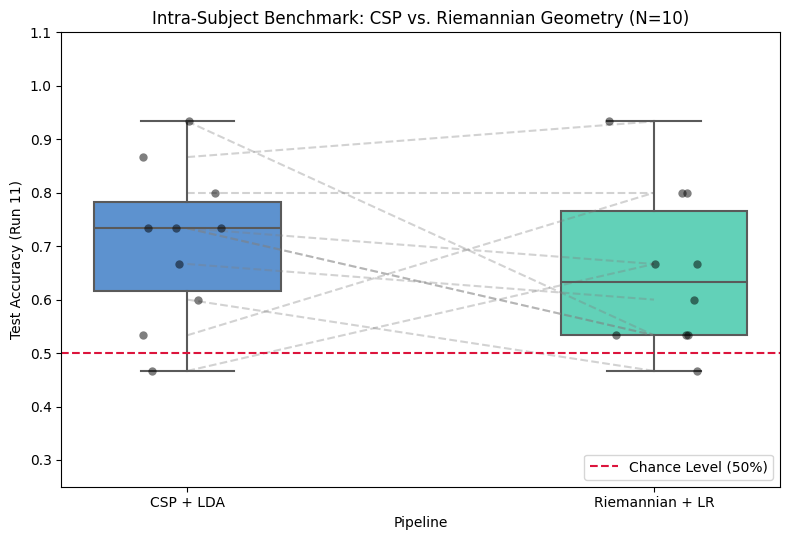

In [35]:
# Inferential Statistics: CSP vs RG Intra-Subject
n = len(df_intra)

mean_csp = df_intra['CSP_Accuracy'].mean()
sem_csp = df_intra['CSP_Accuracy'].std(ddof=1) / np.sqrt(n)

mean_rg = df_intra['RG_Accuracy'].mean()
sem_rg = df_intra['RG_Accuracy'].std(ddof=1) / np.sqrt(n)

# Single-sample tests vs 50% chance
t_csp, p_csp_two = stats.ttest_1samp(df_intra['CSP_Accuracy'], popmean=0.50)
p_csp_one = p_csp_two / 2 if t_csp > 0 else 1.0 - (p_csp_two / 2)

t_rg, p_rg_two = stats.ttest_1samp(df_intra['RG_Accuracy'], popmean=0.50)
p_rg_one = p_rg_two / 2 if t_rg > 0 else 1.0 - (p_rg_two / 2)

# Paired test (RG vs CSP on the exact same brains)
t_paired, p_paired = stats.ttest_rel(df_intra['RG_Accuracy'], df_intra['CSP_Accuracy'])

print("\n" + "=" * 55)
print(f"Cohort Size: {n} subjects evaluated")
print(f"CSP+LDA Mean: {mean_csp:.2%} ± {sem_csp:.2%} SEM | p(1-tailed) = {p_csp_one:.4e}")
print(f"RG+LR Mean:   {mean_rg:.2%} ± {sem_rg:.2%} SEM | p(1-tailed) = {p_rg_one:.4e}")
print(f"Paired Difference (RG - CSP): {(mean_rg - mean_csp):.2%}")
print(f"Paired t-test: t({n-1}) = {t_paired:.3f}, p = {p_paired:.4e}")
print("=" * 55)

# Reshape for Seaborn plot
df_melt = df_intra.melt(id_vars=["Subject"], value_vars=["CSP_Accuracy", "RG_Accuracy"], 
                        var_name="Pipeline", value_name="Accuracy")
df_melt["Pipeline"] = df_melt["Pipeline"].replace({
    "CSP_Accuracy": "CSP + LDA", 
    "RG_Accuracy": "Riemannian + LR"
})

plt.figure(figsize=(8, 5.5))
sns.boxplot(x="Pipeline", y="Accuracy", data=df_melt, palette=["#4A90E2", "#50E3C2"], width=0.4)
sns.stripplot(x="Pipeline", y="Accuracy", data=df_melt, color="black", alpha=0.5, jitter=0.1, size=6)

# Connect individual subjects across conditions
for sub in df_intra["Subject"].unique():
    sub_data = df_intra[df_intra["Subject"] == sub]
    plt.plot([0, 1], [sub_data["CSP_Accuracy"].values[0], sub_data["RG_Accuracy"].values[0]], 
             color="gray", linestyle="--", alpha=0.35, zorder=1)

plt.axhline(0.50, color="crimson", linestyle="--", linewidth=1.5, label="Chance Level (50%)")
plt.ylim(0.25, 1.1)
plt.ylabel(f"Test Accuracy (Run {RUNS_FOR_TESTING[0]})")
plt.title(f"Intra-Subject Benchmark: CSP vs. Riemannian Geometry (N={n})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()